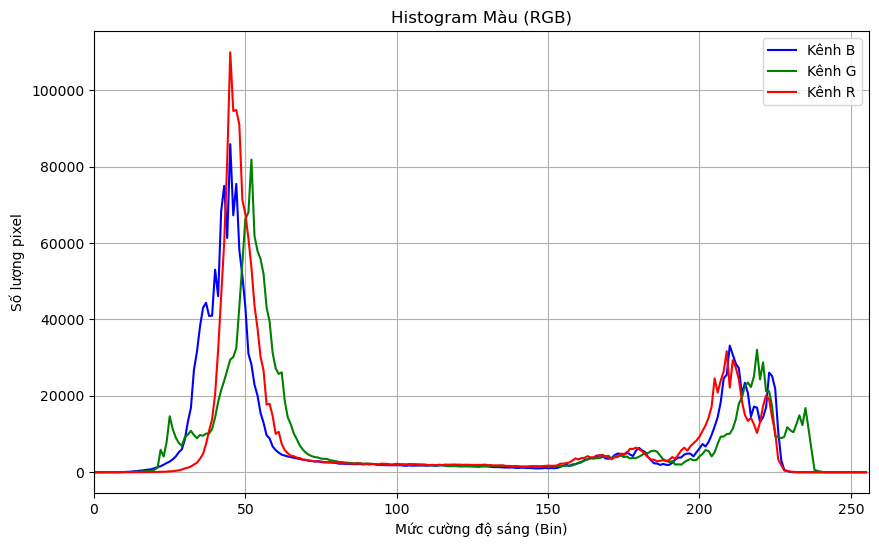

In [15]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. Đọc ảnh
image_path = 'sample_img/phase1/phase1_output.png' # Thay đổi đường dẫn ảnh tại đây
img = cv2.imread(image_path)

if img is None:
    print("Không thể đọc ảnh. Vui lòng kiểm tra lại đường dẫn.")
else:
    # OpenCV đọc ảnh theo thứ tự BGR, cần chuyển sang RGB để hiển thị đúng màu
    # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Định nghĩa các kênh màu và màu sắc tương ứng để vẽ
    colors = ('b', 'g', 'r') # B, G, R
    
    plt.figure(figsize=(10, 6))
    plt.title("Histogram Màu (RGB)")
    plt.xlabel("Mức cường độ sáng (Bin)")
    plt.ylabel("Số lượng pixel")

    # 3. Tính toán và vẽ histogram cho từng kênh
    for i, col in enumerate(colors):
        # cv2.calcHist([image], channels, mask, histSize, ranges)
        hist = cv2.calcHist([img], [i], None, [256], [0, 256])
        plt.plot(hist, color=col, label=f'Kênh {col.upper()}')
        plt.xlim([0, 256])

    plt.legend()
    plt.grid(True)
    plt.show()


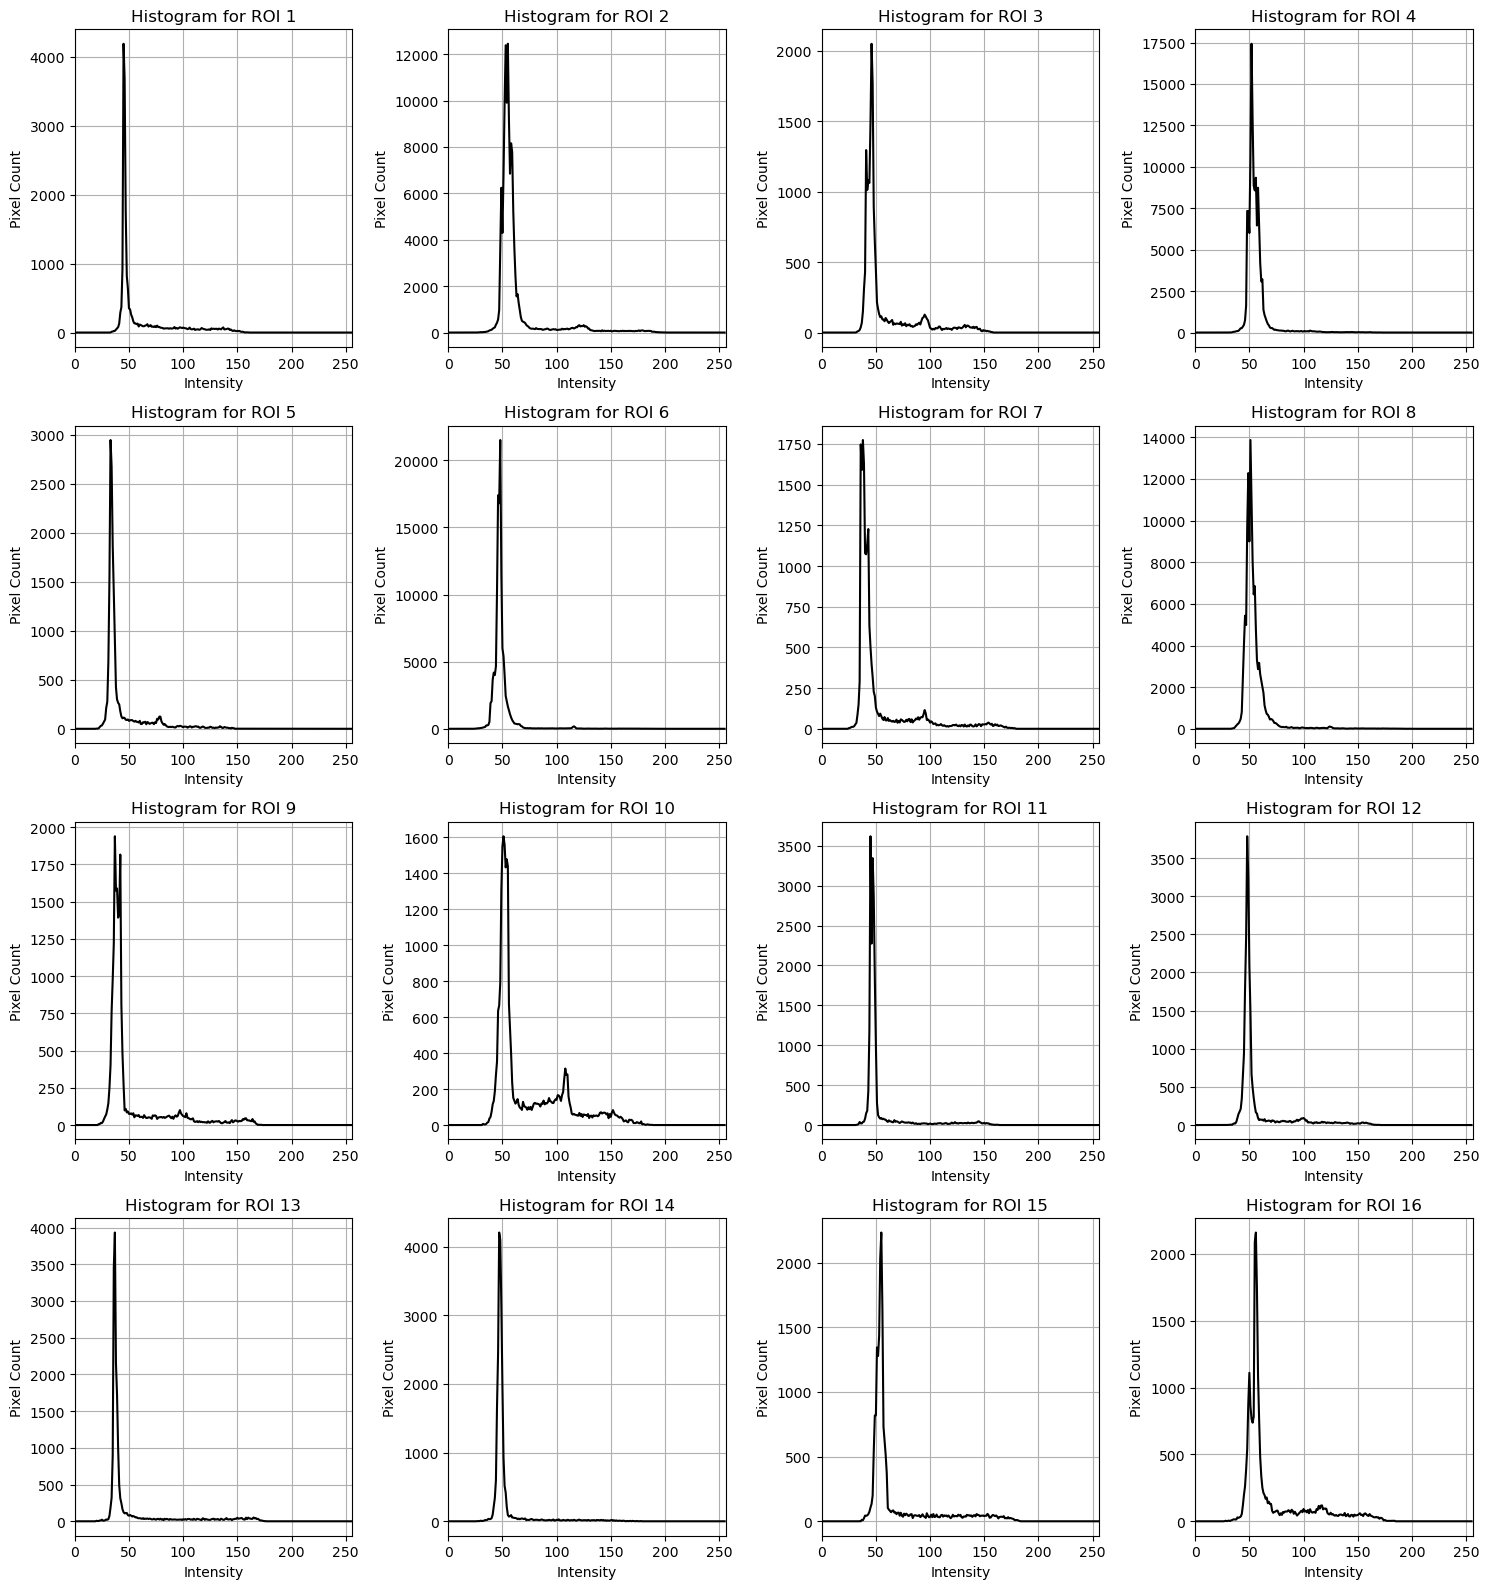

In [16]:
import json

# Load ROIs from the JSON file
with open('lane_rois.json', 'r') as f:
    rois = json.load(f)

# Load the image
image_path = 'sample_img/phase2/phase2_masked_lanes.png'
img = cv2.imread(image_path)
    # Convert image to grayscale
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Create a figure to hold all the histograms
num_rois = len(rois)
cols = 4  # Number of columns for subplots
rows = (num_rois + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten() # Flatten the 2D array of axes

for i, (x, y, w, h) in enumerate(rois):
    # Crop the ROI from the grayscale image
    roi_gray = gray_img[y:y+h, x:x+w]
    
    if roi_gray.size == 0:
        print(f"ROI {i+1} is empty. Skipping.")
        continue

    # Calculate histogram for the ROI
    hist = cv2.calcHist([roi_gray], [0], None, [256], [0, 256])

    # Plot the histogram on the i-th subplot
    ax = axes[i]
    ax.plot(hist, color='black')
    ax.set_title(f'Histogram for ROI {i+1}')
    ax.set_xlabel('Intensity')
    ax.set_ylabel('Pixel Count')
    ax.set_xlim([0, 256])
    ax.grid(True)

    # Hide any unused subplots
    # for j in range(i + 1, len(axes)):
    #     axes[j].set_visible(False)

plt.tight_layout()
# plt.show()


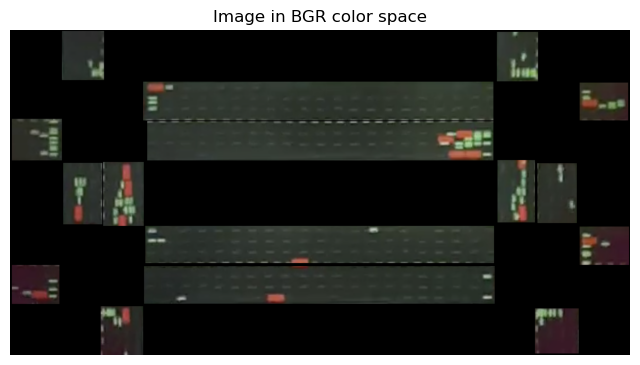

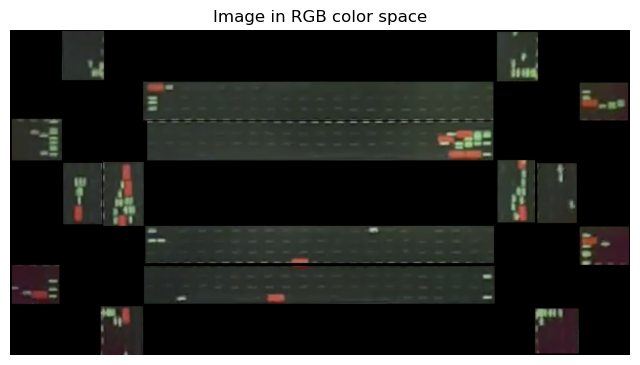

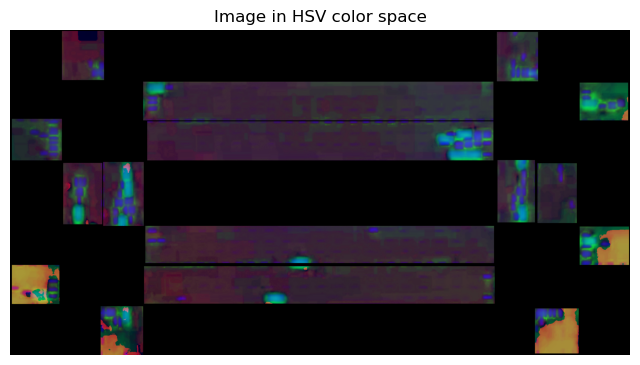

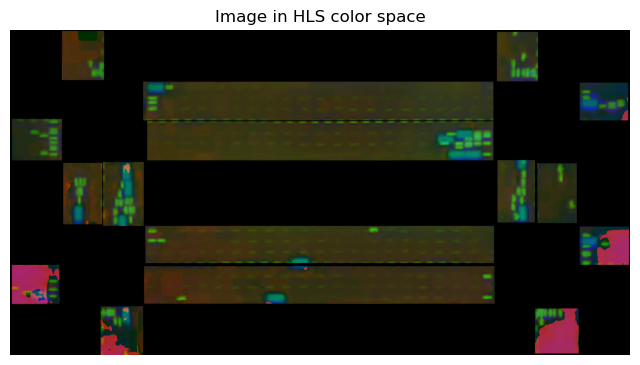

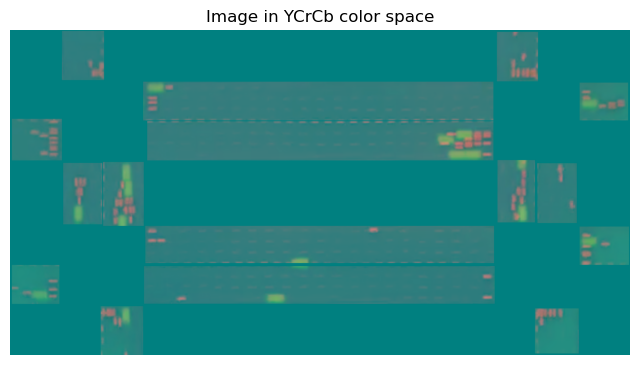

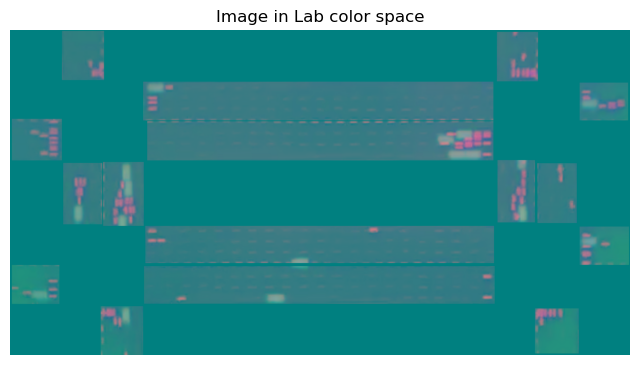

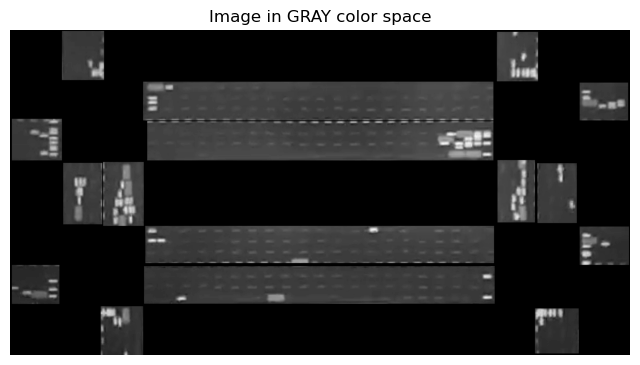

In [ ]:
# Load the image
image_path = 'sample_img/phase2/phase2_masked_lanes.png'
img_bgr = cv2.imread(image_path)

if img_bgr is None:
    print(f"Could not read image from {image_path}")
else:
    # Dictionary of color spaces and their conversion codes from BGR
    color_spaces = {
        'BGR': None,  # Original, no conversion needed
        'RGB': cv2.COLOR_BGR2RGB,
        'HSV': cv2.COLOR_BGR2HSV,
        'HLS': cv2.COLOR_BGR2HLS,
        'YCrCb': cv2.COLOR_BGR2YCrCb,
        'Lab': cv2.COLOR_BGR2Lab,
        'GRAY': cv2.COLOR_BGR2GRAY
    }

    for name, code in color_spaces.items():
        plt.figure(figsize=(8, 6))
        
        if code is not None:
            # Convert the image
            converted_img = cv2.cvtColor(img_bgr, code)
        else:
            # This is for the original BGR image
            converted_img = img_bgr.copy()

        # Display the image
        # For single-channel images like GRAY, we need a colormap.
        # For multi-channel images, matplotlib expects RGB, so we handle BGR and others.
        if name == 'GRAY':
            plt.imshow(converted_img, cmap='gray')
        elif name == 'BGR':
             # Matplotlib expects RGB, so we convert BGR to RGB for display
            plt.imshow(cv2.cvtColor(converted_img, cv2.COLOR_BGR2RGB))
        else:
            plt.imshow(converted_img)
            
        plt.title(f'Image in {name} color space')
        plt.axis('off') # Hide axes
        plt.show()


In [4]:
# read file sample_img/sample.png and file sample_img/phase1_output.png and print size of this image

import matplotlib.pyplot as plt

image0_path = 'sample_img/debug_video/frame_300.jpg'
image0 = plt.imread(image0_path)

# Load the first image
image1_path = 'sample_img/sample.png'
image1 = plt.imread(image1_path)
# Load the second image
image2_path = 'sample_img/phase1/phase1_output.png'
image2 = plt.imread(image2_path)

image3_path = 'sample_img/phase1/phase1_output_frame0.png'
image3 = plt.imread(image3_path)

print(f"Size of image 0 (frame_0.jpg): {image0.shape}")
print(f"Size of image 1 (sample.png): {image1.shape}")
print(f"Size of image 2 (phase1_output.png): {image2.shape}")
print(f"Size of image 3 (phase1_output_frame0.png): {image3.shape}")

Size of image 0 (frame_0.jpg): (480, 640, 3)
Size of image 1 (sample.png): (1678, 2252, 4)
Size of image 2 (phase1_output.png): (1032, 1970, 3)
Size of image 3 (phase1_output_frame0.png): (291, 555, 3)


In [ ]:
# Size of image 0 (frame_0.jpg): (480, 640, 3)
# Size of image 1 (sample.png): (1678, 2252, 4)
# Size of image 2 (phase1_output.png): (1032, 1970, 3)
# Size of image 3 (phase1_output_frame0.png): (291, 555, 3)